# Differentially Private Random Forest Classifier - Breast Cancer Wisconsin Dataset

This notebook implements a Differentially Private Random Forest classifier using `diffprivlib` on the Wisconsin Breast Cancer dataset and compares its performance with the standard (non-private) model.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    f1_score,
    precision_score,
    recall_score,
)
from diffprivlib.models import RandomForestClassifier as DPRandomForestClassifier
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics



## 2. Load preprocessed data saved from STD_RF.ipynb

In [2]:
import pickle
# Load the scaled data
with open("../data/processed_data.pkl", "rb") as f: 
    loaded_data = pickle.load(f)

X_train, X_test = loaded_data["X_train"], loaded_data["X_test"]
y_train, y_test = loaded_data["y_train"], loaded_data["y_test"]
bounds = loaded_data['bounds']

## 3. Load Baseline Results

In [3]:
# Load baseline results from standard model
try:
    baseline_df = pd.read_csv('baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print("Baseline results loaded successfully!")
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: baseline_results.csv not found. Please run STD_RF.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded successfully!
Baseline Accuracy: 0.9573
Baseline F1-Score: 0.9390


## 5. Train Differentially Private Random Forest Model

In [4]:
# Define epsilon value for differential privacy
epsilon = 1.0
N_RUNS = 30

# Store per-run metrics for the detailed evaluation at epsilon=1.0
detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_cms = []  # confusion matrices
 
print(f"Training DP Random Forest {N_RUNS} times with epsilon={epsilon}...")
print("=" * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS): 
    seed = run * 10 + 42 # fix sequence for the reproducibility
    # Initialize and train DP Random Forest Classifier
    dp_rf_model = DPRandomForestClassifier(
        n_estimators=20,
        epsilon=epsilon,
        random_state=seed,
        n_jobs=-1,
        max_depth=4, 
        bounds=bounds
    )


    _t0 = time.perf_counter()
    dp_rf_model.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0

    y_dp_pred = dp_rf_model.predict(X_test)
    # Calculate metrics
    dp_accuracy = accuracy_score(y_test, y_dp_pred)
    detail_extra.add(y_test, y_dp_pred, model=dp_rf_model, X=X_test, train_time=train_time)
    dp_f1 = f1_score(y_test, y_dp_pred)
    dp_precision = precision_score(y_test, y_dp_pred)
    dp_recall = recall_score(y_test, y_dp_pred)
    cm = confusion_matrix(y_test, y_dp_pred)

    detail_accuracies.append(dp_accuracy)
    detail_f1s.append(dp_f1)
    detail_precisions.append(dp_precision)
    detail_recalls.append(dp_recall)
    detail_cms.append(cm)


    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {dp_accuracy:.4f} | F1: {dp_f1:.4f} | Prec: {dp_precision:.4f} | Rec: {dp_recall:.4f}")


print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP Random Forest 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.7456 | F1: 0.4727 | Prec: 1.0000 | Rec: 0.3095
  Run  2/30 | Acc: 0.7456 | F1: 0.4727 | Prec: 1.0000 | Rec: 0.3095
  Run  3/30 | Acc: 0.6579 | F1: 0.1333 | Prec: 1.0000 | Rec: 0.0714
  Run  4/30 | Acc: 0.6930 | F1: 0.2857 | Prec: 1.0000 | Rec: 0.1667


  Run  5/30 | Acc: 0.6491 | F1: 0.0909 | Prec: 1.0000 | Rec: 0.0476
  Run  6/30 | Acc: 0.7456 | F1: 0.4727 | Prec: 1.0000 | Rec: 0.3095
  Run  7/30 | Acc: 0.7018 | F1: 0.3200 | Prec: 1.0000 | Rec: 0.1905
  Run  8/30 | Acc: 0.7719 | F1: 0.5517 | Prec: 1.0000 | Rec: 0.3810
  Run  9/30 | Acc: 0.8860 | F1: 0.8169 | Prec: 1.0000 | Rec: 0.6905


  Run 10/30 | Acc: 0.6667 | F1: 0.1739 | Prec: 1.0000 | Rec: 0.0952
  Run 11/30 | Acc: 0.7982 | F1: 0.6349 | Prec: 0.9524 | Rec: 0.4762
  Run 12/30 | Acc: 0.6579 | F1: 0.1333 | Prec: 1.0000 | Rec: 0.0714
  Run 13/30 | Acc: 0.7281 | F1: 0.4151 | Prec: 1.0000 | Rec: 0.2619


  Run 14/30 | Acc: 0.6404 | F1: 0.0465 | Prec: 1.0000 | Rec: 0.0238
  Run 15/30 | Acc: 0.8509 | F1: 0.7463 | Prec: 1.0000 | Rec: 0.5952
  Run 16/30 | Acc: 0.6491 | F1: 0.0909 | Prec: 1.0000 | Rec: 0.0476
  Run 17/30 | Acc: 0.6491 | F1: 0.0909 | Prec: 1.0000 | Rec: 0.0476


  Run 18/30 | Acc: 0.7281 | F1: 0.4364 | Prec: 0.9231 | Rec: 0.2857
  Run 19/30 | Acc: 0.6667 | F1: 0.1739 | Prec: 1.0000 | Rec: 0.0952
  Run 20/30 | Acc: 0.6842 | F1: 0.2500 | Prec: 1.0000 | Rec: 0.1429
  Run 21/30 | Acc: 0.6930 | F1: 0.2857 | Prec: 1.0000 | Rec: 0.1667
  Run 22/30 | Acc: 0.6842 | F1: 0.2500 | Prec: 1.0000 | Rec: 0.1429


  Run 23/30 | Acc: 0.6667 | F1: 0.1739 | Prec: 1.0000 | Rec: 0.0952
  Run 24/30 | Acc: 0.8509 | F1: 0.7536 | Prec: 0.9630 | Rec: 0.6190
  Run 25/30 | Acc: 0.8070 | F1: 0.6452 | Prec: 1.0000 | Rec: 0.4762
  Run 26/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run 27/30 | Acc: 0.6930 | F1: 0.2857 | Prec: 1.0000 | Rec: 0.1667


  Run 28/30 | Acc: 0.6491 | F1: 0.0909 | Prec: 1.0000 | Rec: 0.0476
  Run 29/30 | Acc: 0.6667 | F1: 0.1739 | Prec: 1.0000 | Rec: 0.0952
  Run 30/30 | Acc: 0.7982 | F1: 0.6230 | Prec: 1.0000 | Rec: 0.4524
Added metrics over the detail runs:
  Balanced Acc:   0.6140 ± 0.0946
  AUROC:          0.9583 ± 0.0218
  Train Time (s): 0.0209 ± 0.0054


## 6. Model Evaluation

In [5]:
avg_accuracy = float(np.mean(detail_accuracies))
avg_f1_score = float(np.mean(detail_f1s))
avg_precision = float(np.mean(detail_precisions))
avg_recall = float(np.mean(detail_recalls))

std_accuracy = float(np.std(detail_accuracies))
std_f1_score = float(np.std(detail_f1s))
std_precision = float(np.std(detail_precisions))
std_recall = float(np.std(detail_recalls))

print("=" * 60)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {avg_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"  F1-Score:  {avg_f1_score:.4f} ± {std_f1_score:.4f}")
print(f"  Precision: {avg_precision:.4f} ± {std_precision:.4f}")
print(f"  Recall:    {avg_recall:.4f} ± {std_recall:.4f}")



Results over 30 runs at epsilon=1.0:
  Accuracy:  0.7152 ± 0.0693
  F1-Score:  0.3364 ± 0.2314
  Precision: 0.9613 ± 0.1793
  Recall:    0.2294 ± 0.1909


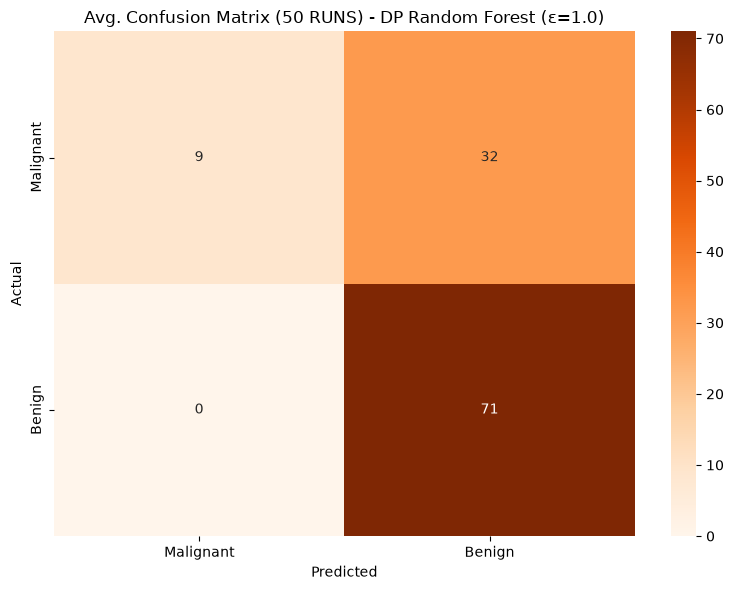


Confusion Matrix:
[[ 9 32]
 [ 0 71]]


In [6]:
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN], 
    [FP, TN]
])

plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
#             xticklabels=['Benign', 'Malignant'],
#             yticklabels=['Benign', 'Malignant'])
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title(f'Avg. Confusion Matrix (50 RUNS) - DP Random Forest (ε={epsilon})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)

## 7. Compare with Baseline (Standard Model)

In [7]:
if baseline_accuracy is not None:
    accuracy_loss = baseline_accuracy - avg_accuracy
    f1_loss = baseline_f1 - avg_f1_score
    
    print("=" * 50)
    print("COMPARISON: Standard vs DP Random Forest")
    print("=" * 50)
    print(f"\nStandard Model Accuracy: {baseline_accuracy:.4f}")
    print(f"DP Model Accuracy (avg): {avg_accuracy:.4f}")
    print(f"Accuracy Loss:           {accuracy_loss:.4f} ({accuracy_loss*100:.2f}%)")
    print(f"\nStandard Model F1-Score: {baseline_f1:.4f}")
    print(f"DP Model F1-Score (avg): {avg_f1_score:.4f}")
    print(f"F1 Loss:                 {f1_loss:.4f} ({f1_loss*100:.2f}%)")
else:
    print("Baseline results not available. Run STD_RF.ipynb first.")

COMPARISON: Standard vs DP Random Forest

Standard Model Accuracy: 0.9573
DP Model Accuracy (avg): 0.7152
Accuracy Loss:           0.2421 (24.21%)

Standard Model F1-Score: 0.9390
DP Model F1-Score (avg): 0.3364
F1 Loss:                 0.6027 (60.27%)


## Preparing the Json dump

In [8]:
import json
 
N_RUNS = 30  # runs per epsilon value
 
parameters = {
    "n_estimators": 20,
    "random_state": "varies (20 seeds per epsilon)",
    "n_jobs": -1,
    "max_depth": 4,
    "n_runs": N_RUNS,
}
 
results_json = {
    "model_type": "Differentially Private Random Forest",
    "n_runs_per_epsilon": N_RUNS,
    "epsilon_results": {}
}

## 8. Epsilon vs Accuracy Analysis

Testing different privacy budget (epsilon) values to observe the trade-off between privacy and accuracy.

In [9]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
 
# Store aggregated results
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'precision_std': [],
    'recall_mean': [],
    'recall_std': [],
}
 
print(f"Training DP Random Forest with {N_RUNS} runs per epsilon value...")
print("=" * 80)
 
for eps in epsilon_values:
    # Collect metrics across N_RUNS runs
    run_accuracies = []
    run_f1s = []
    run_precisions = []
    run_recalls = []
    run_cms = []
 
    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42  # different seed each run
 
        dp_model = DPRandomForestClassifier(
            n_estimators=20,
            epsilon=eps,
            random_state=seed,
            n_jobs=-1,
            max_depth=4,
            bounds=bounds
        )
        _t0 = time.perf_counter()
        dp_model.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_model.predict(X_test)
 
        acc = accuracy_score(y_test, y_pred)
        extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        cm = confusion_matrix(y_test, y_pred)
 
        run_accuracies.append(acc)
        run_f1s.append(f1)
        run_precisions.append(prec)
        run_recalls.append(rec)
        run_cms.append(cm.tolist())
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_model, f'output/model/dp_rf_model_eps_{eps}.pkl')
 
    # Compute statistics
    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)
 
    # Store aggregated results
    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)
 
    # Store detailed results in JSON
    results_json["epsilon_results"][str(eps)] = {
        "epsilon": float(eps),
        "n_runs": N_RUNS,
        "accuracy_mean": acc_mean,
        "accuracy_std": acc_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
        "precision_mean": prec_mean,
        "precision_std": prec_std,
        "recall_mean": rec_mean,
        "recall_std": rec_std,
        "per_run_accuracies": run_accuracies,
        "per_run_f1s": run_f1s,
        "per_run_precisions": run_precisions,
        "per_run_recalls": run_recalls,
        "per_run_confusion_matrices": run_cms,
        "parameters": parameters.copy()
    }
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())
 
    print(f"ε={eps:5.1f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | "
          f"F1: {f1_mean:.4f}±{f1_std:.4f} | "
          f"Prec: {prec_mean:.4f}±{prec_std:.4f} | "
          f"Rec: {rec_mean:.4f}±{rec_std:.4f}")
 
print("=" * 80)
print("Training complete!")

Training DP Random Forest with 30 runs per epsilon value...


Model successfully exported to output/model/dp_rf_model_eps_0.1.pkl


ε=  0.1 | Acc: 0.7006±0.0571 | F1: 0.3195±0.2322 | Prec: 0.8333±0.3000 | Rec: 0.2389±0.2253
Model successfully exported to output/model/dp_rf_model_eps_0.2.pkl


ε=  0.2 | Acc: 0.7079±0.0769 | F1: 0.2994±0.2738 | Prec: 0.7897±0.3958 | Rec: 0.2127±0.2162
Model successfully exported to output/model/dp_rf_model_eps_0.4.pkl


ε=  0.4 | Acc: 0.7029±0.0665 | F1: 0.2892±0.2436 | Prec: 0.7616±0.4207 | Rec: 0.1952±0.1820
Model successfully exported to output/model/dp_rf_model_eps_0.6.pkl


...

ε=  2.0 | Acc: 0.7178±0.0716 | F1: 0.3449±0.2283 | Prec: 0.9955±0.0171 | Rec: 0.2365±0.1985
Model successfully exported to output/model/dp_rf_model_eps_4.0.pkl


ε=  4.0 | Acc: 0.7199±0.0723 | F1: 0.3521±0.2278 | Prec: 0.9957±0.0163 | Rec: 0.2421±0.2004
Model successfully exported to output/model/dp_rf_model_eps_6.0.pkl


ε=  6.0 | Acc: 0.7199±0.0723 | F1: 0.3521±0.2278 | Prec: 0.9957±0.0163 | Rec: 0.2421±0.2004
Model successfully exported to output/model/dp_rf_model_eps_8.0.pkl


ε=  8.0 | Acc: 0.7199±0.0723 | F1: 0.3521±0.2278 | Prec: 0.9957±0.0163 | Rec: 0.2421±0.2004
Model successfully exported to output/model/dp_rf_model_eps_10.0.pkl


ε= 10.0 | Acc: 0.7199±0.0723 | F1: 0.3521±0.2278 | Prec: 0.9957±0.0163 | Rec: 0.2421±0.2004
Training complete!


In [10]:
# Save to JSON file
with open('dp_rf_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("Results saved to 'dp_rf_report.json'")
print(f"Total epsilon values: {len(results_json['epsilon_results'])}")

Results saved to 'dp_rf_report.json'
Total epsilon values: 15


In [11]:
results_df = pd.DataFrame(results)
 
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = baseline_accuracy - results_df['accuracy_mean']
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100
 
print(f"\nResults Summary ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


Results Summary (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.700585      0.057062       0.319451      0.232242        0.833295       0.299994     0.238889    0.225331                0.604398               0.087898      0.847867     0.108285         0.018596        0.004643            0.256725          25.672515
     0.2       0.707895      0.076945       0.299365      0.273814        0.789653       0.395832     0.212698    0.216211                0.604729               0.105902      0.918309     0.044987         0.026847        0.008567            0.249415          24.941520
     0.4       0.702924      0.066525       0.289195      0.243604        0.761574       0.420661     0.195238    0.181994                0.597156       

## 9. Visualization: Privacy Budget vs Accuracy Loss

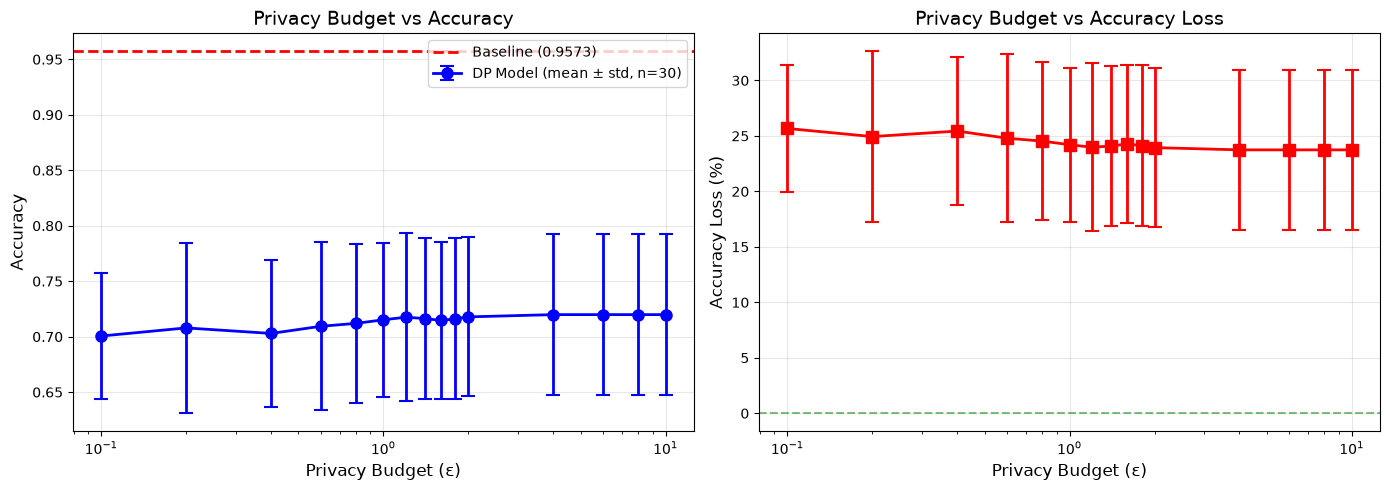


Plot saved as 'privacy_accuracy_tradeoff.png'


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1: Epsilon vs Accuracy (with error bars)
ax1 = axes[0]
ax1.errorbar(
    results_df['epsilon'],
    results_df['accuracy_mean'],
    yerr=results_df['accuracy_std'],
    fmt='bo-', linewidth=2, markersize=8,
    capsize=5, capthick=1.5,
    label=f'DP Model (mean ± std, n={N_RUNS})'
)
if baseline_accuracy is not None:
    ax1.axhline(y=baseline_accuracy, color='r', linestyle='--',
                linewidth=2, label=f'Baseline ({baseline_accuracy:.4f})')
ax1.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Privacy Budget vs Accuracy', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')


# Plot 2: Epsilon vs Accuracy Loss (with error bars)
if baseline_accuracy is not None:
    ax2 = axes[1]
    ax2.errorbar(
        results_df['epsilon'],
        results_df['accuracy_loss_pct'],
        yerr=results_df['accuracy_std'] * 100,  # std in percentage
        fmt='rs-', linewidth=2, markersize=8,
        capsize=5, capthick=1.5
    )
    ax2.set_xlabel('Privacy Budget (ε)', fontsize=12)
    ax2.set_ylabel('Accuracy Loss (%)', fontsize=12)
    ax2.set_title('Privacy Budget vs Accuracy Loss', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.axhline(y=0, color='g', linestyle='--', alpha=0.5)
 
plt.tight_layout()
plt.savefig('privacy_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'privacy_accuracy_tradeoff.png'")

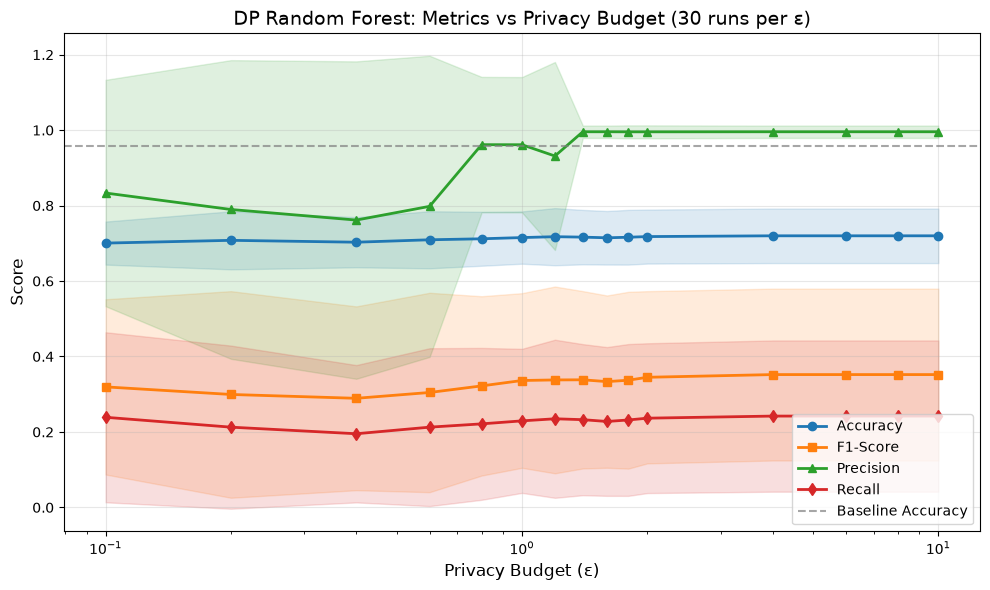

Plot saved as 'all_metrics_vs_epsilon.png'


In [13]:
plt.figure(figsize=(10, 6))
 
metrics = [
    ('accuracy_mean', 'accuracy_std', 'Accuracy', 'o-'),
    ('f1_score_mean', 'f1_score_std', 'F1-Score', 's-'),
    ('precision_mean', 'precision_std', 'Precision', '^-'),
    ('recall_mean', 'recall_std', 'Recall', 'd-'),
]
 
for mean_col, std_col, label, fmt in metrics:
    mean_vals = results_df[mean_col].values
    std_vals = results_df[std_col].values
    eps_vals = results_df['epsilon'].values
 
    line = plt.plot(eps_vals, mean_vals, fmt, label=label, linewidth=2)
    color = line[0].get_color()
 
    # Shaded confidence band (mean ± 1 std)
    plt.fill_between(
        eps_vals,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.15,
        color=color
    )
 
if baseline_accuracy is not None:
    plt.axhline(y=baseline_accuracy, color='gray', linestyle='--',
                alpha=0.7, label='Baseline Accuracy')
 
plt.xlabel('Privacy Budget (ε)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'DP Random Forest: Metrics vs Privacy Budget ({N_RUNS} runs per ε)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.savefig('all_metrics_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'all_metrics_vs_epsilon.png'")
 

## 10. Save Results

In [14]:
# ==========================================================================
# SECTION 10 REPLACEMENT: Save Results (replaces Cell 82)
# ==========================================================================
results_df.to_csv('dp_results.csv', index=False)
print("DP results saved to 'dp_results.csv'")
 
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
if baseline_accuracy is not None:
    print(f"\nBaseline (Standard RF) Accuracy: {baseline_accuracy:.4f}")
print(f"\nDP Random Forest Results ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))

DP results saved to 'dp_results.csv'

FINAL SUMMARY

Baseline (Standard RF) Accuracy: 0.9573

DP Random Forest Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.700585      0.057062       0.319451      0.232242        0.833295       0.299994     0.238889    0.225331                0.604398               0.087898      0.847867     0.108285         0.018596        0.004643            0.256725          25.672515
     0.2       0.707895      0.076945       0.299365      0.273814        0.789653       0.395832     0.212698    0.216211                0.604729               0.105902      0.918309     0.044987         0.026847        0.008567            0.249415          24.941520
     0.4       0.702924      0.066525       0.28919